# SignalObjExamples

Python port of the MATLAB `SignalObjExamples` helpfile (`helpfiles/SignalObjExamples.m`). Faithfully reproduces each example figure using the `nstat.SignalObj` API.

In [ ]:
# nSTAT-python notebook example: SignalObjExamples
from pathlib import Path
import sys

REPO_ROOT = Path.cwd().resolve().parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import numpy as np

from nstat import SignalObj
from nstat.notebook_figures import FigureTracker

np.random.seed(0)
OUTPUT_ROOT = REPO_ROOT / "output" / "notebook_images"
__tracker = FigureTracker(topic="SignalObjExamples", output_root=OUTPUT_ROOT, expected_count=17)

sampleRate = 100
t = np.arange(0, 10 + 1 / sampleRate, 1 / sampleRate)
freq = 2
v1 = np.sin(2 * np.pi * freq * t)
v2 = np.sin(v1 ** 2)
v = np.vstack([v1, v2])


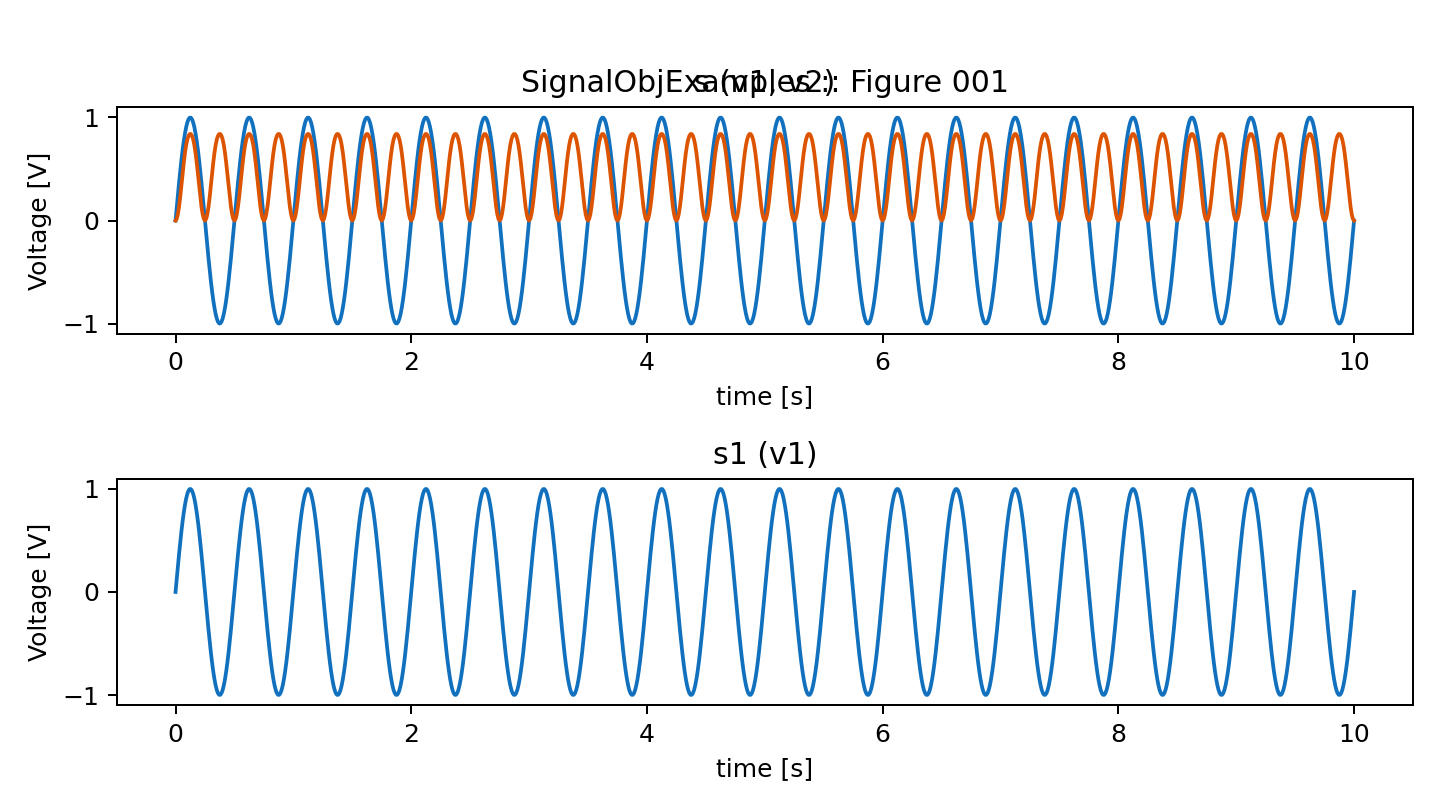

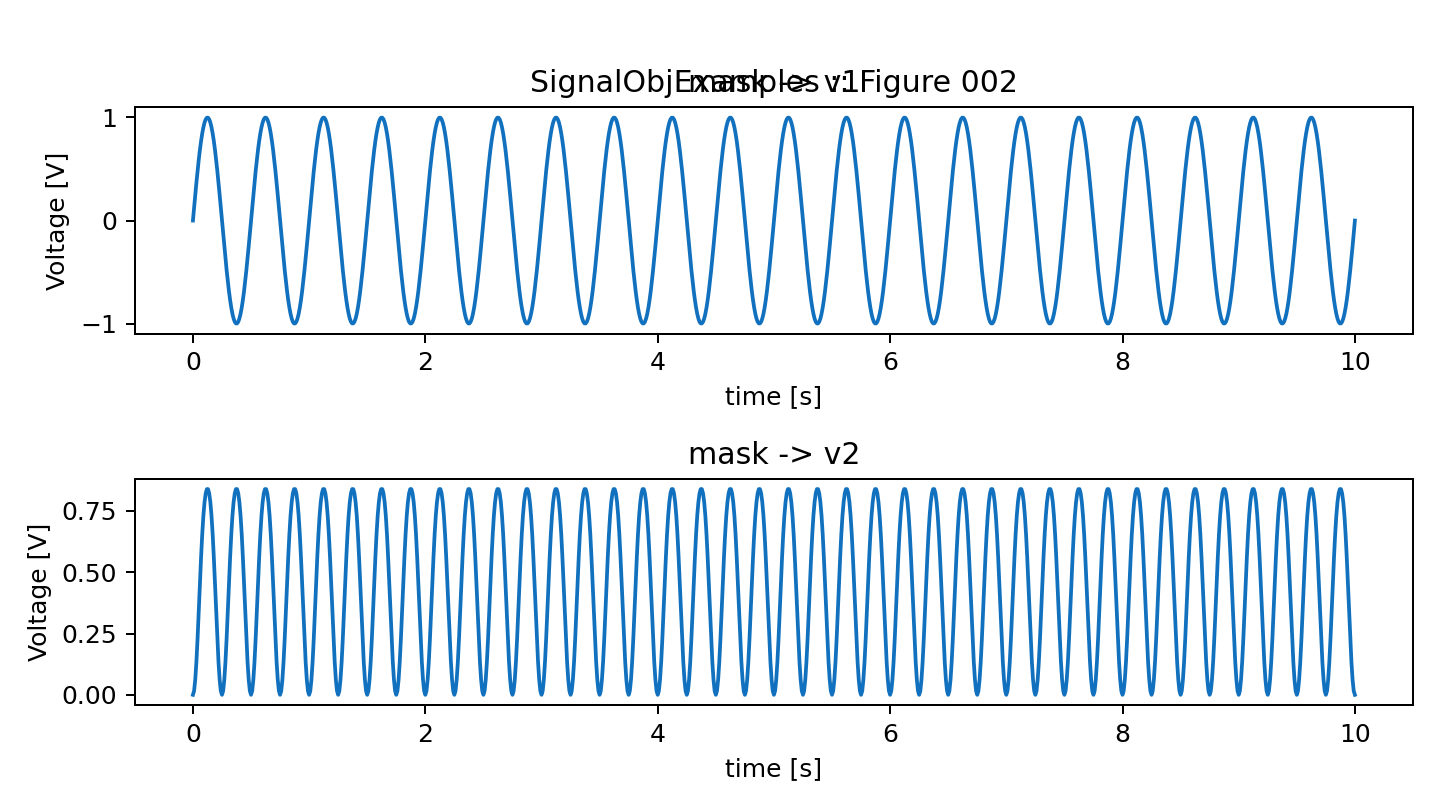

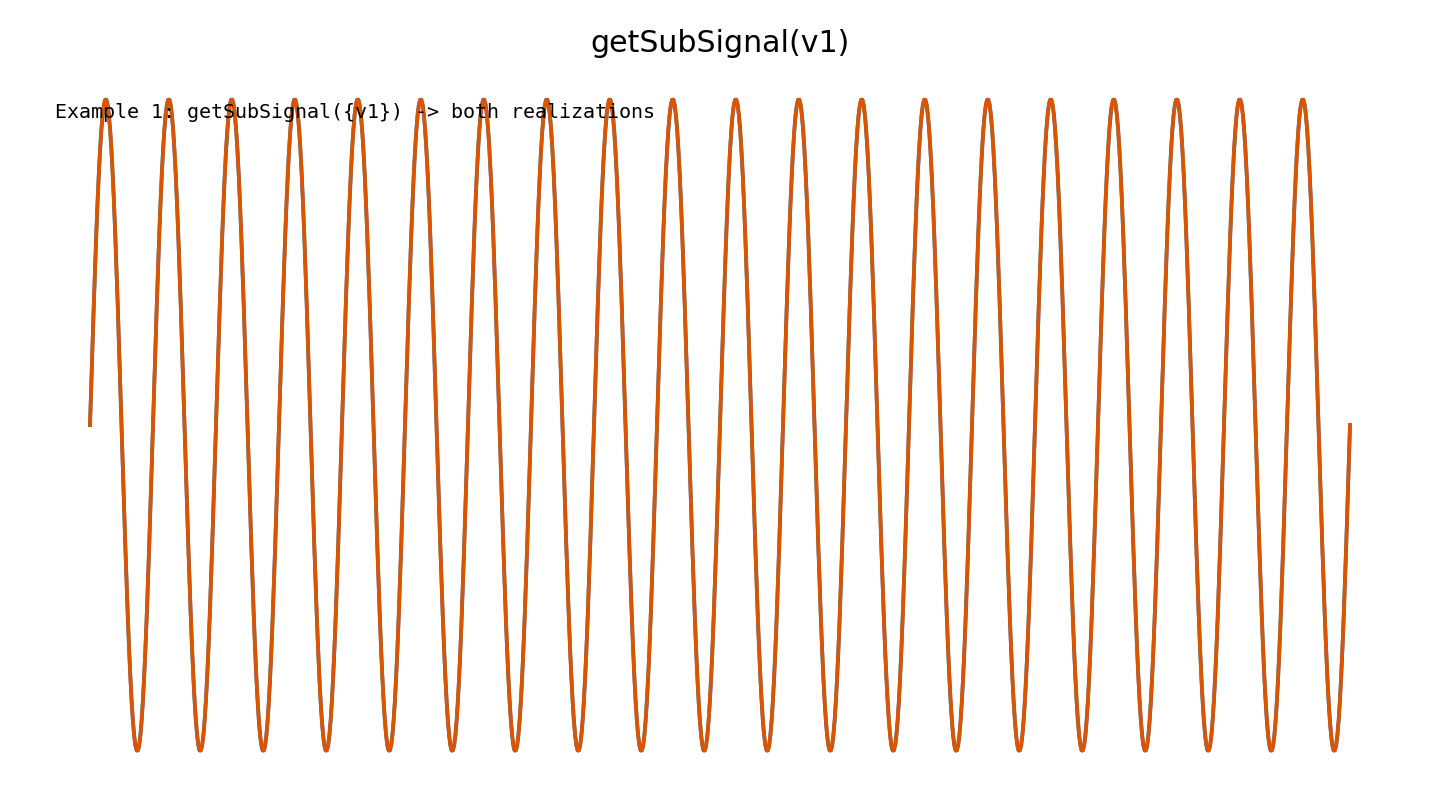

In [ ]:
# Example 1: Defining and Plotting Signals
s = SignalObj(t, v, "Voltage", "time", "s", "V", ["v1", "v2"])
s1 = SignalObj(t, v1, "Voltage", "time", "s", "V", ["v1"])
__tracker.new_figure("Example 1: define + plot s and s1")
plt.subplot(2, 1, 1); s.plot(); plt.title("s (v1, v2)")
plt.subplot(2, 1, 2); s1.plot(); plt.title("s1 (v1)")
plt.tight_layout()

# Masking: show only v1, then only v2
__tracker.new_figure("Example 1: masked views of s")
plt.subplot(2, 1, 1); s.setMask(["v1"]); s.plot(); s.resetMask(); plt.title("mask -> v1")
plt.subplot(2, 1, 2); s.setMask(["v2"]); s.plot(); s.resetMask(); plt.title("mask -> v2")
plt.tight_layout()

# Repeated dataLabels: two realizations of v1
sr3 = SignalObj(t, np.vstack([v1, v1, v2]), "Voltage", "time", "s", "V", ["v1", "v1", "v2"])
__tracker.new_figure("Example 1: getSubSignal({v1}) -> both realizations")
sr3.getSubSignal(["v1"]).plot(); plt.title("getSubSignal(v1)")
plt.tight_layout()


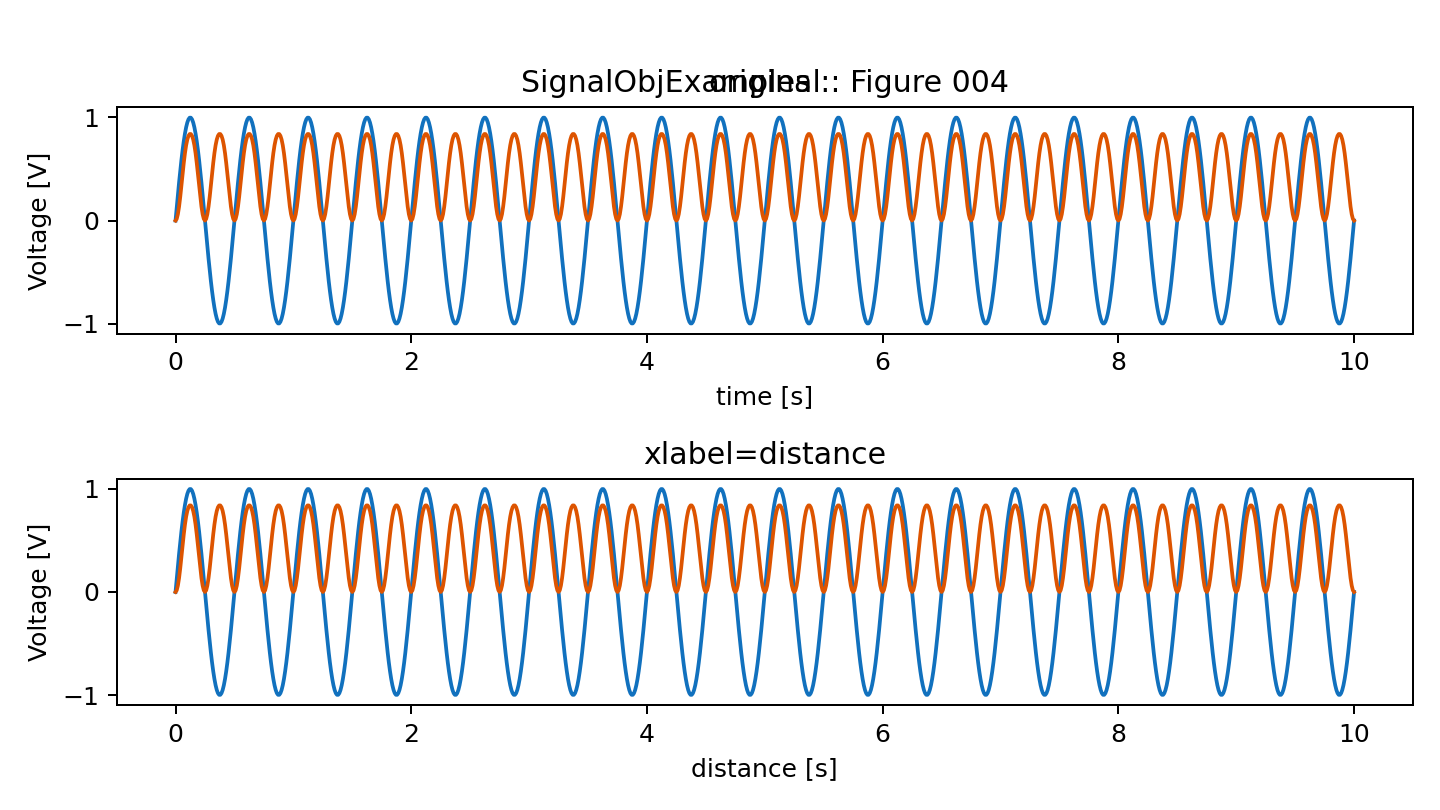

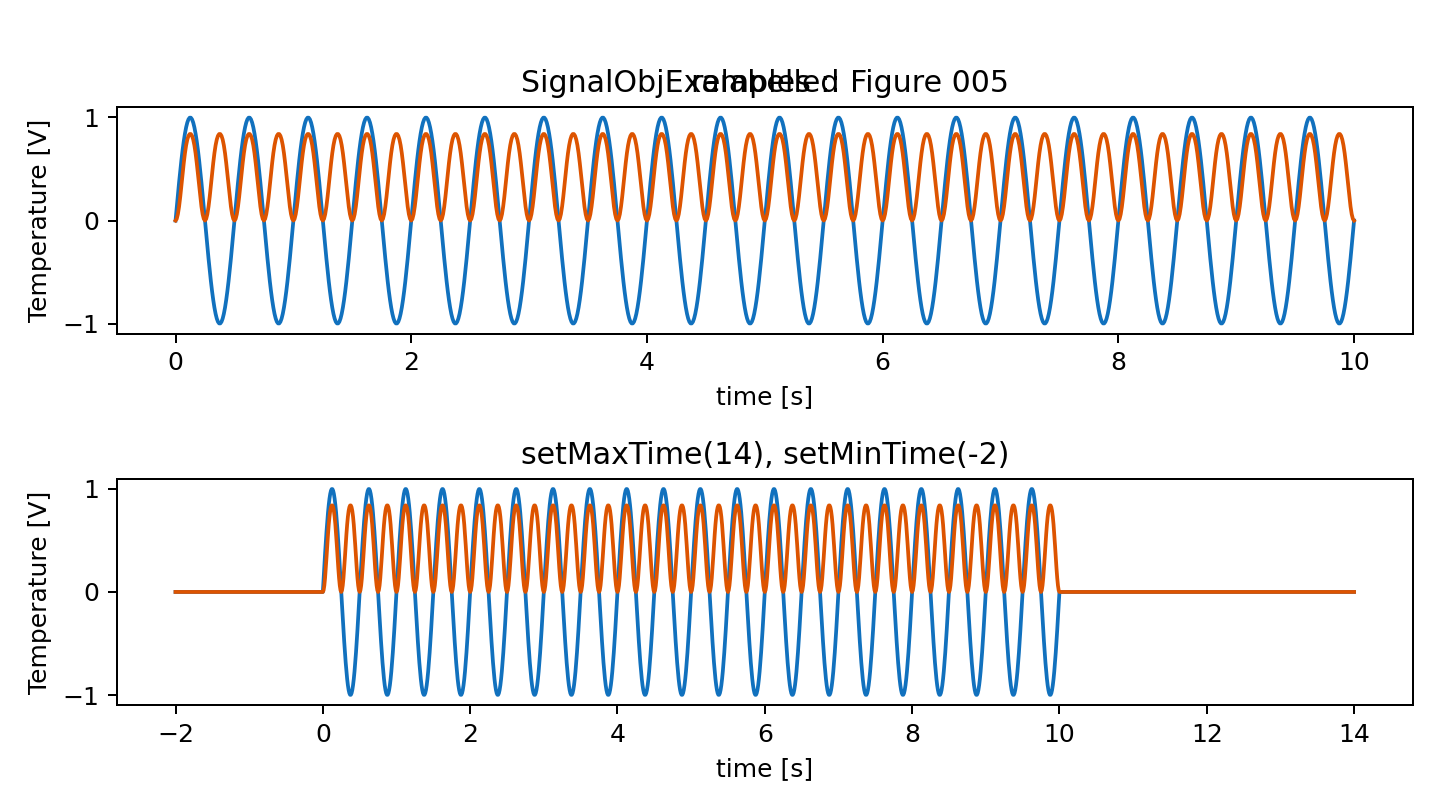

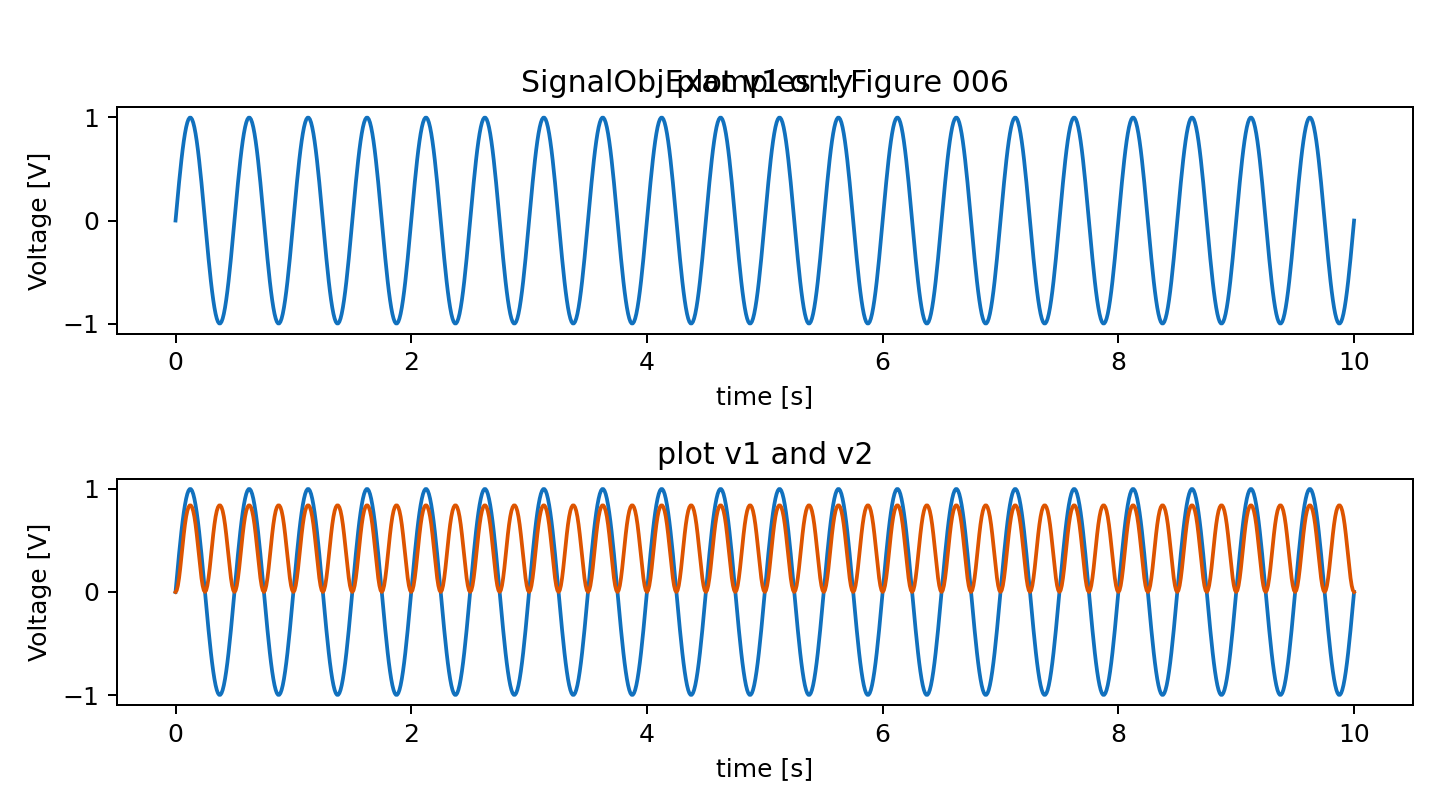

In [ ]:
# Example 2: Changing Signal Properties
s = SignalObj(t, v, "Voltage", "time", "s", "V", ["v1", "v2"])
__tracker.new_figure("Example 2: change x label/units")
plt.subplot(2, 1, 1); s.plot(); plt.title("original")
plt.subplot(2, 1, 2); s.setXlabel("distance"); s.plot(); plt.title("xlabel=distance")
plt.tight_layout()

s = SignalObj(t, v, "Voltage", "time", "s", "V", ["v1", "v2"])
__tracker.new_figure("Example 2: relabel + time window")
plt.subplot(2, 1, 1); s.setDataLabels(["r1", "r2"]); s.setYLabel("Temperature"); s.plot(); plt.title("relabelled")
plt.subplot(2, 1, 2); s.setMaxTime(14); s.setMinTime(-2); s.plot(); plt.title("setMaxTime(14), setMinTime(-2)")
plt.tight_layout()

s = SignalObj(t, v, "Voltage", "time", "s", "V", ["v1", "v2"])
__tracker.new_figure("Example 2: per-component plot selection")
plt.subplot(2, 1, 1); s.plot("v1"); plt.title("plot v1 only")
plt.subplot(2, 1, 2); s.plot(["v1", "v2"]); plt.title("plot v1 and v2")
plt.tight_layout()


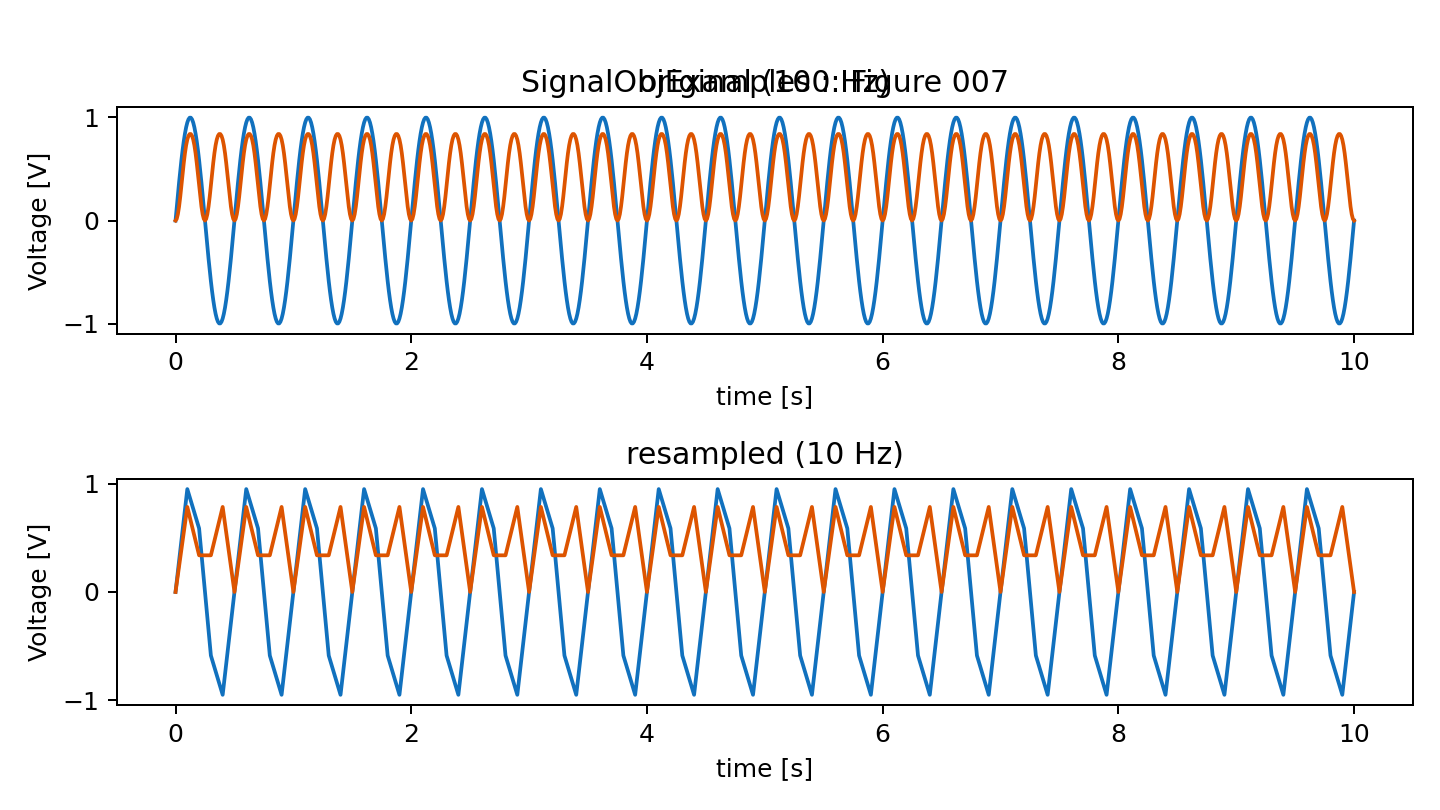

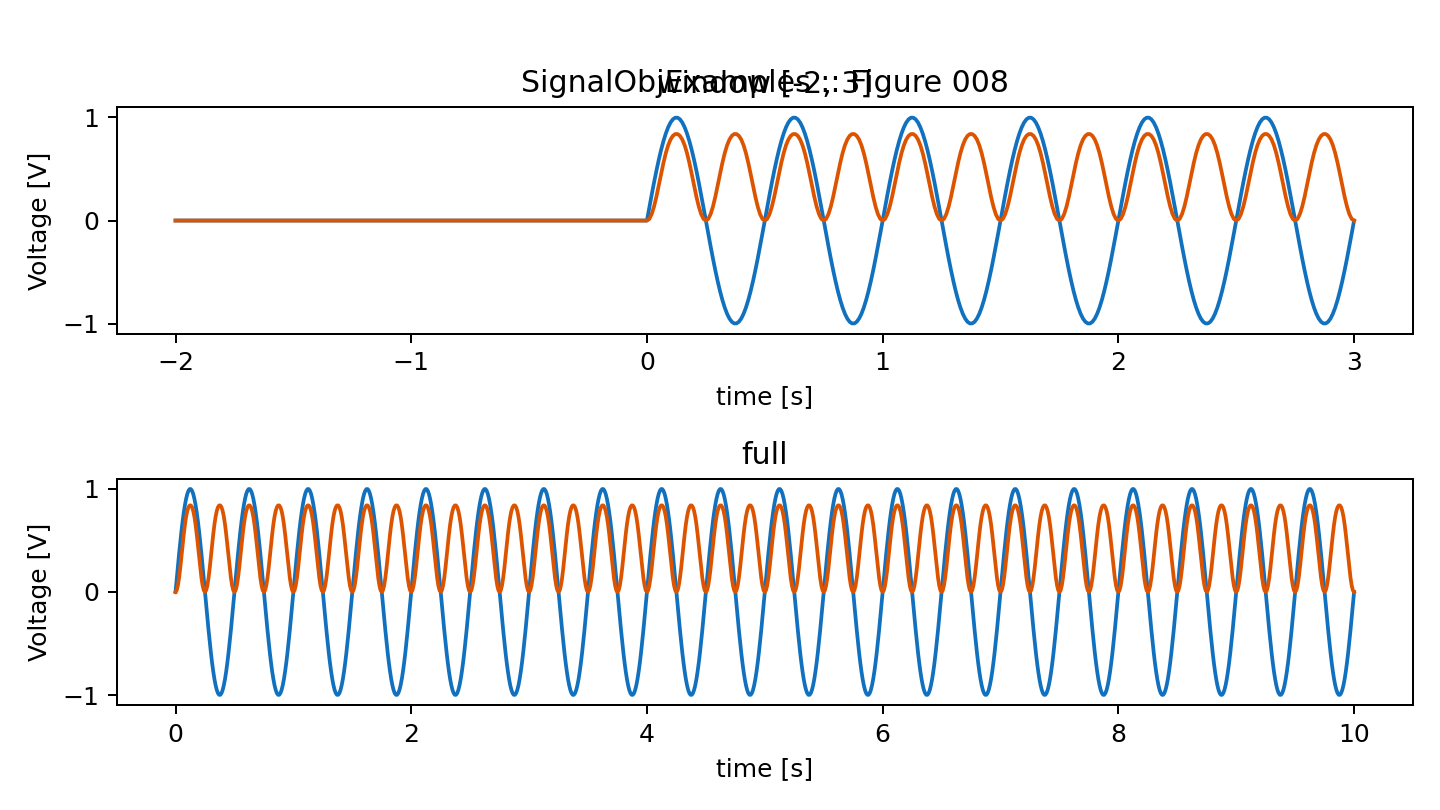

In [ ]:
# Example 3: Resampling and Windowing
s = SignalObj(t, v, "Voltage", "time", "s", "V", ["v1", "v2"])
s1 = s.resample(0.1 * sampleRate)
__tracker.new_figure("Example 3: resample to 0.1*sampleRate")
plt.subplot(2, 1, 1); s.plot(); plt.title("original (100 Hz)")
plt.subplot(2, 1, 2); s1.plot(); plt.title("resampled (10 Hz)")
plt.tight_layout()

__tracker.new_figure("Example 3: getSigInTimeWindow(-2, 3)")
plt.subplot(2, 1, 1); s.getSigInTimeWindow(-2, 3).plot(); plt.title("window [-2, 3]")
plt.subplot(2, 1, 2); s.plot(); plt.title("full")
plt.tight_layout()


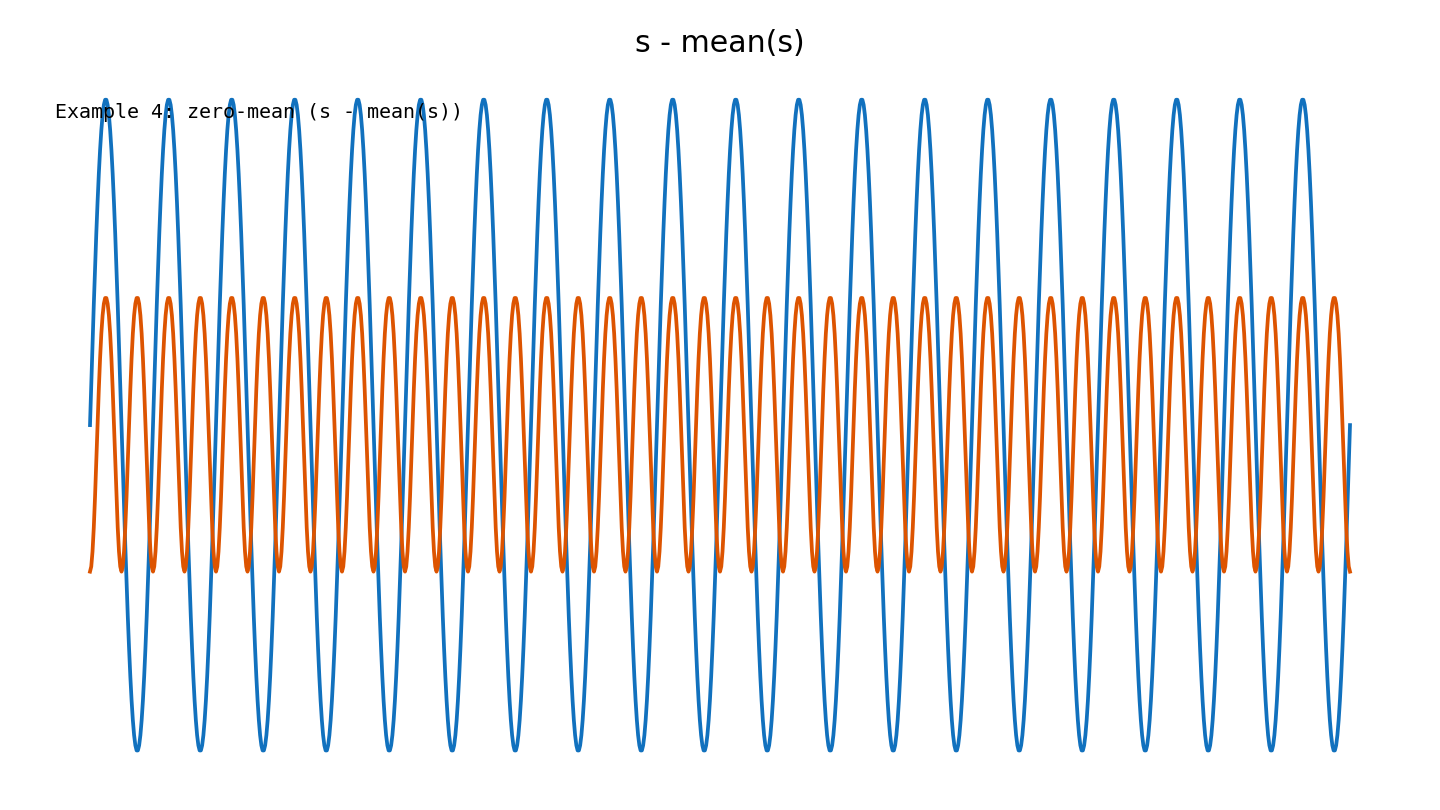

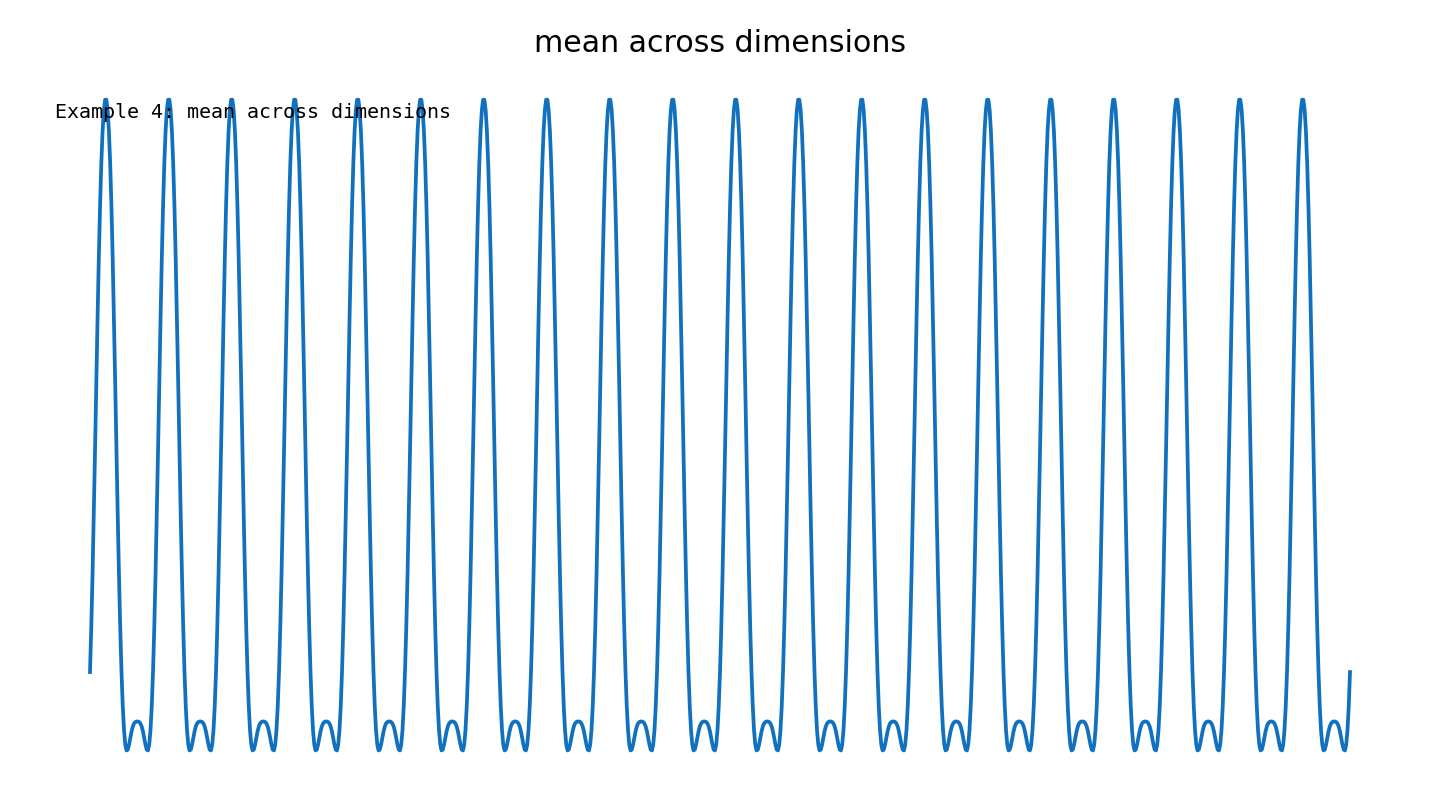

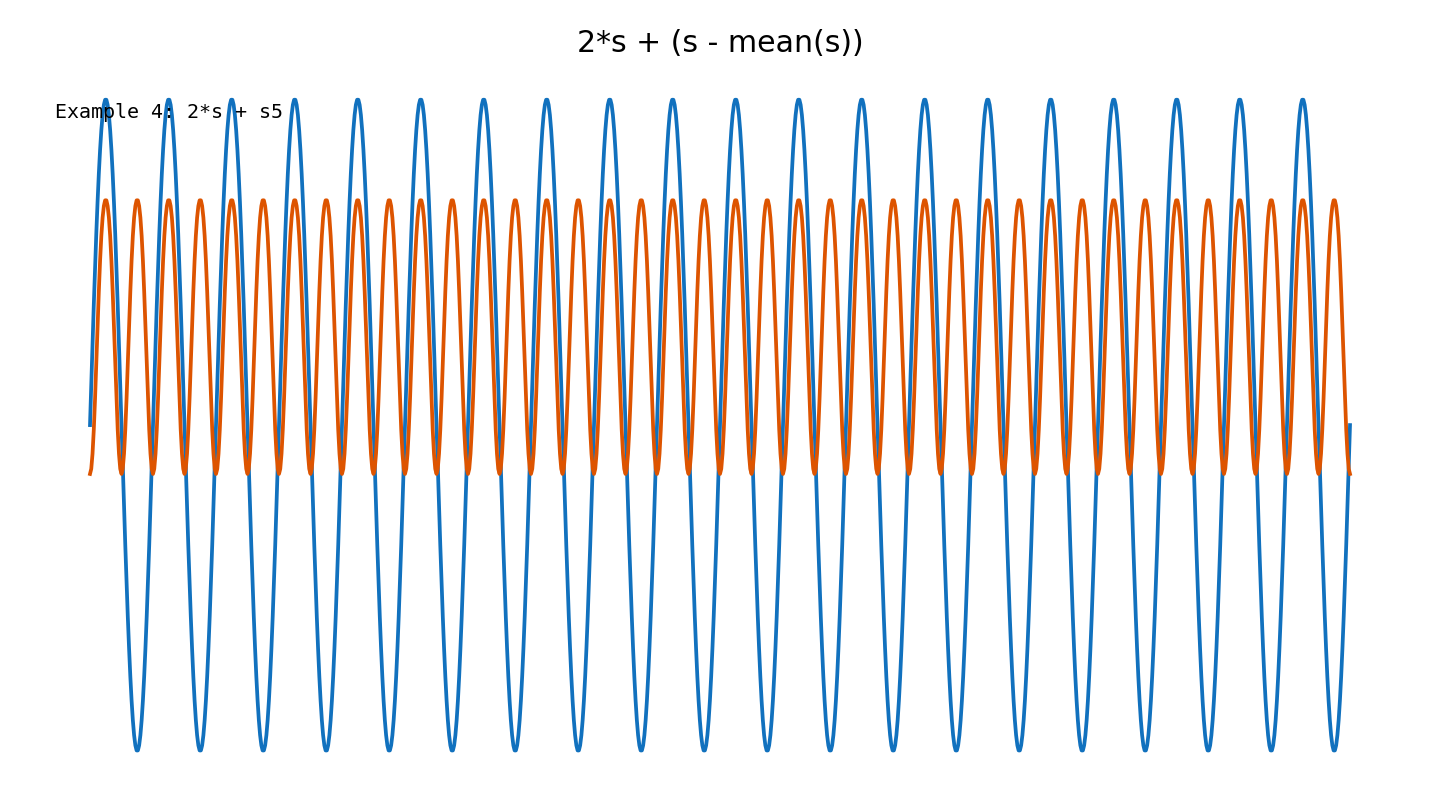

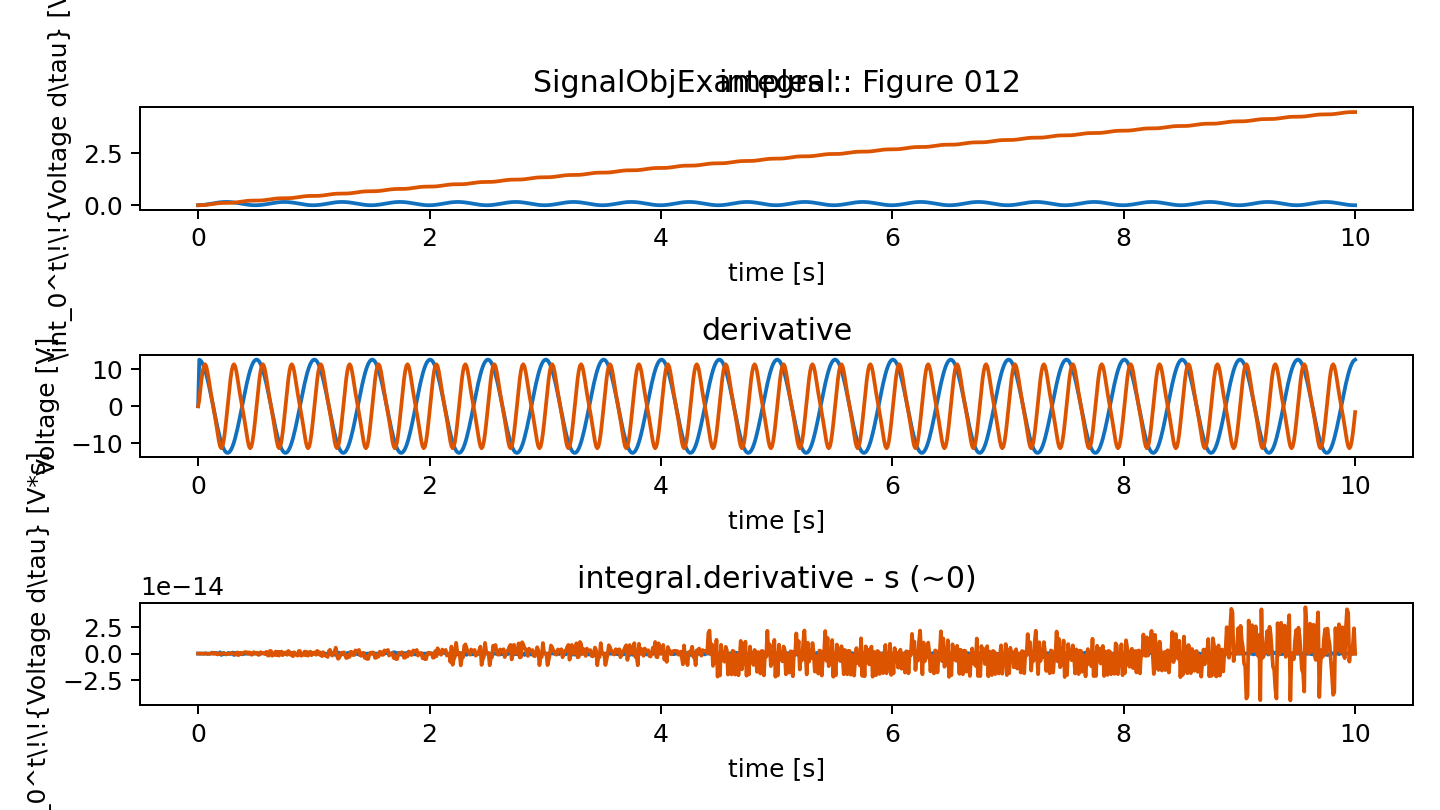

In [ ]:
# Example 4: SignalObj Mathematical Operations
s = SignalObj(t, v, "Voltage", "time", "s", "V", ["v1", "v2"])
s5 = SignalObj(t, v - v.mean(axis=1, keepdims=True), "Voltage", "time", "s", "V", ["v1", "v2"])
__tracker.new_figure("Example 4: zero-mean (s - mean(s))")
s5.plot(); plt.title("s - mean(s)")
plt.tight_layout()

# mean across dimensions -> single averaged signal
sacross = SignalObj(t, v.mean(axis=0), "Voltage", "time", "s", "V", ["mean"])
__tracker.new_figure("Example 4: mean across dimensions")
sacross.plot(); plt.title("mean across dimensions")
plt.tight_layout()

s4 = 2 * s + s5
__tracker.new_figure("Example 4: 2*s + s5")
s4.plot(); plt.title("2*s + (s - mean(s))")
plt.tight_layout()

__tracker.new_figure("Example 4: integral / derivative / round-trip")
plt.subplot(3, 1, 1); s.integral().plot(); plt.title("integral")
plt.subplot(3, 1, 2); s.derivative.plot(); plt.title("derivative")
plt.subplot(3, 1, 3); (s.integral().derivative - s).plot(); plt.title("integral.derivative - s (~0)")
plt.tight_layout()


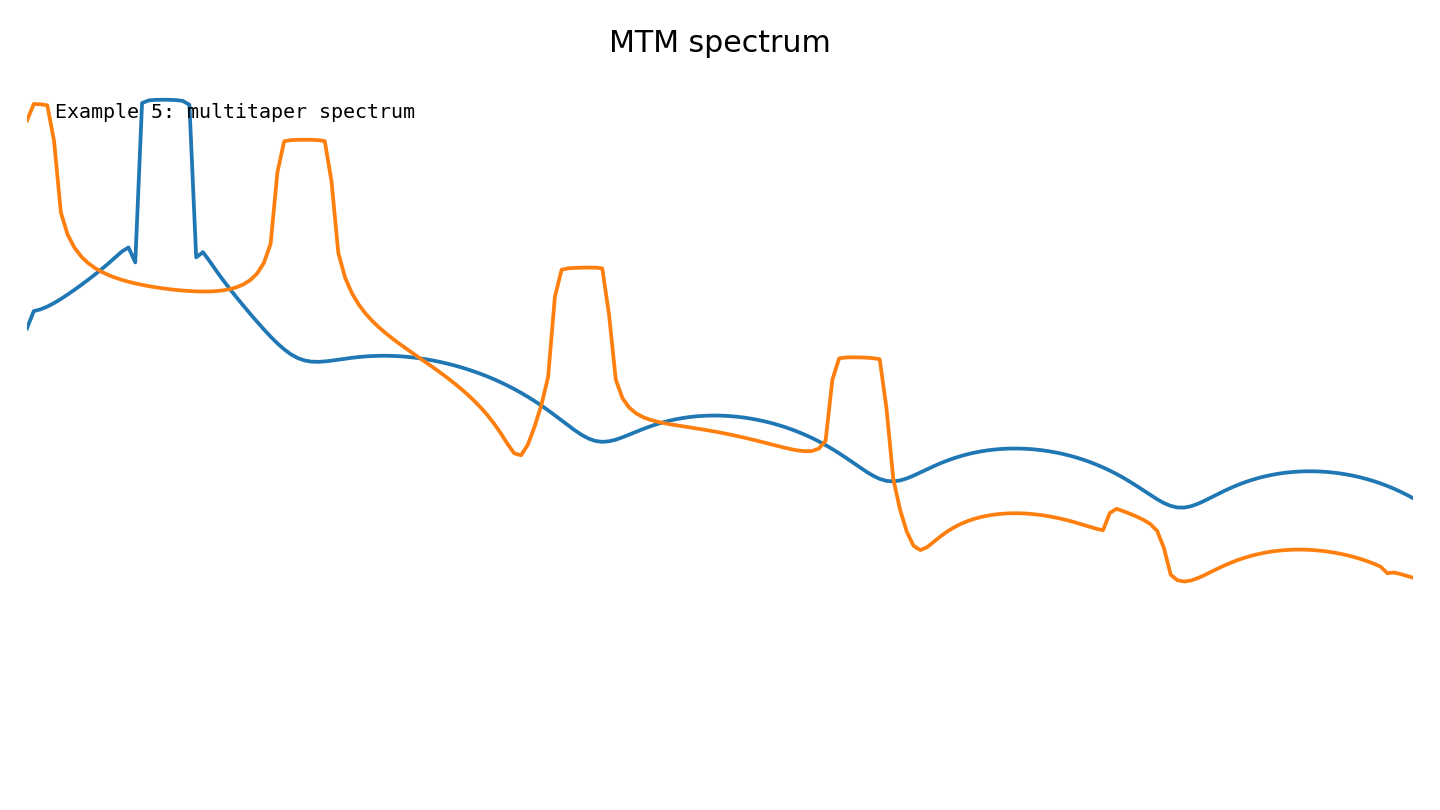

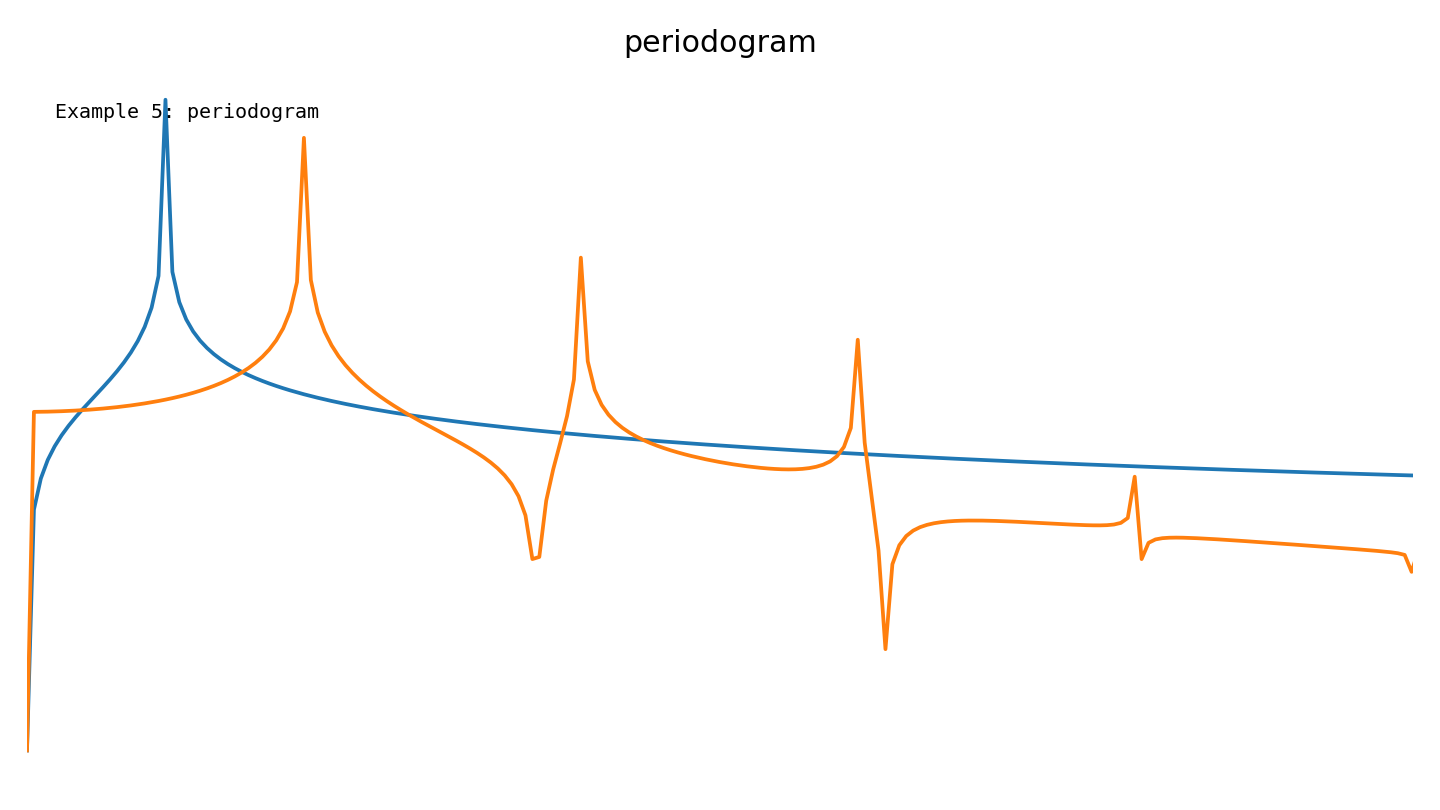

In [ ]:
# Example 5: Spectra
s = SignalObj(t, v, "Voltage", "time", "s", "V", ["v1", "v2"])
f, Smt, _ = s.MTMspectrum()
__tracker.new_figure("Example 5: multitaper spectrum")
plt.plot(f, 10 * np.log10(np.abs(Smt) + 1e-12)); plt.xlabel("Frequency (Hz)"); plt.ylabel("Power (dB)")
plt.title("MTM spectrum"); plt.xlim(0, 20)
plt.tight_layout()

fp, Pp = s.periodogram()
__tracker.new_figure("Example 5: periodogram")
plt.plot(fp, 10 * np.log10(np.abs(Pp) + 1e-12)); plt.xlabel("Frequency (Hz)"); plt.ylabel("Power (dB)")
plt.title("periodogram"); plt.xlim(0, 20)
plt.tight_layout()


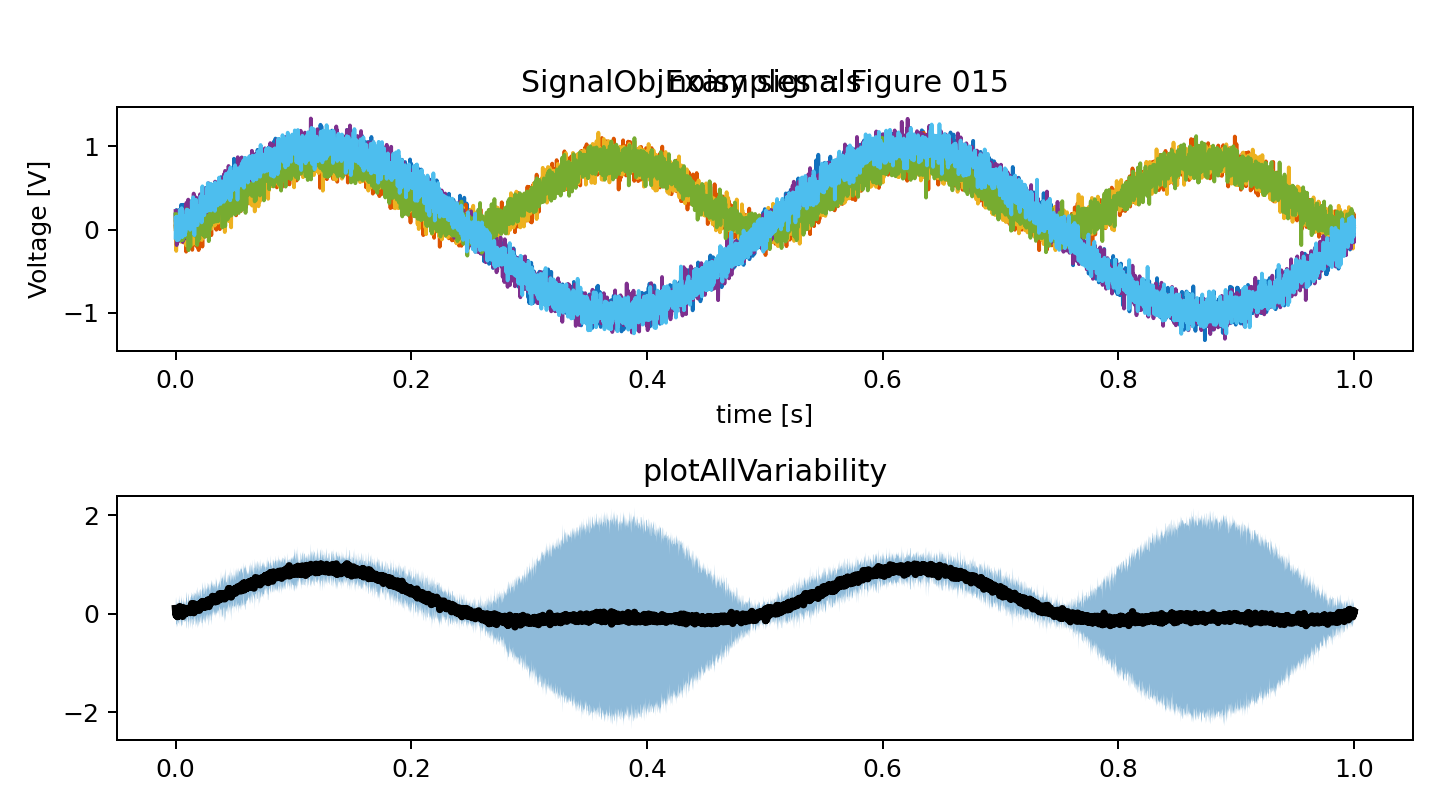

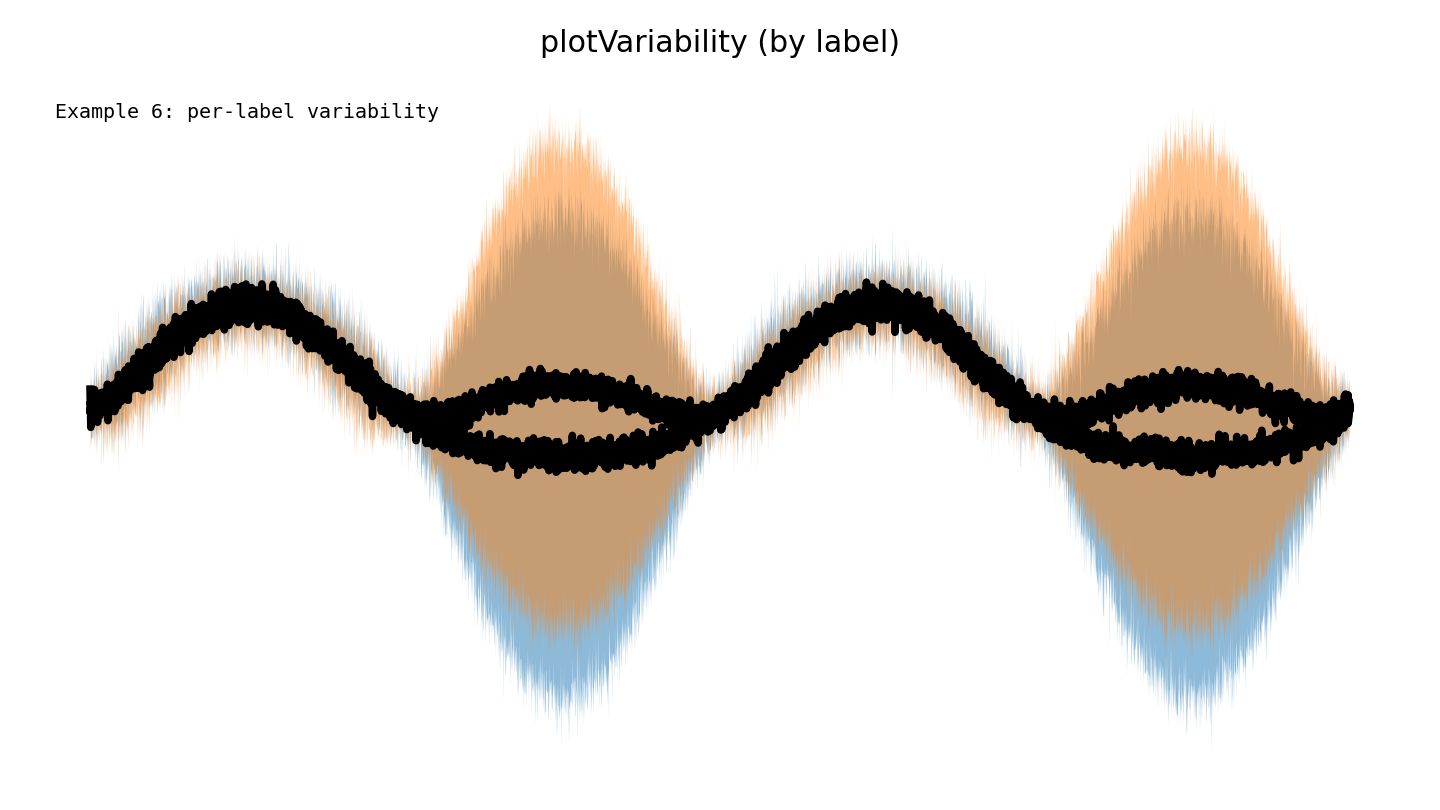

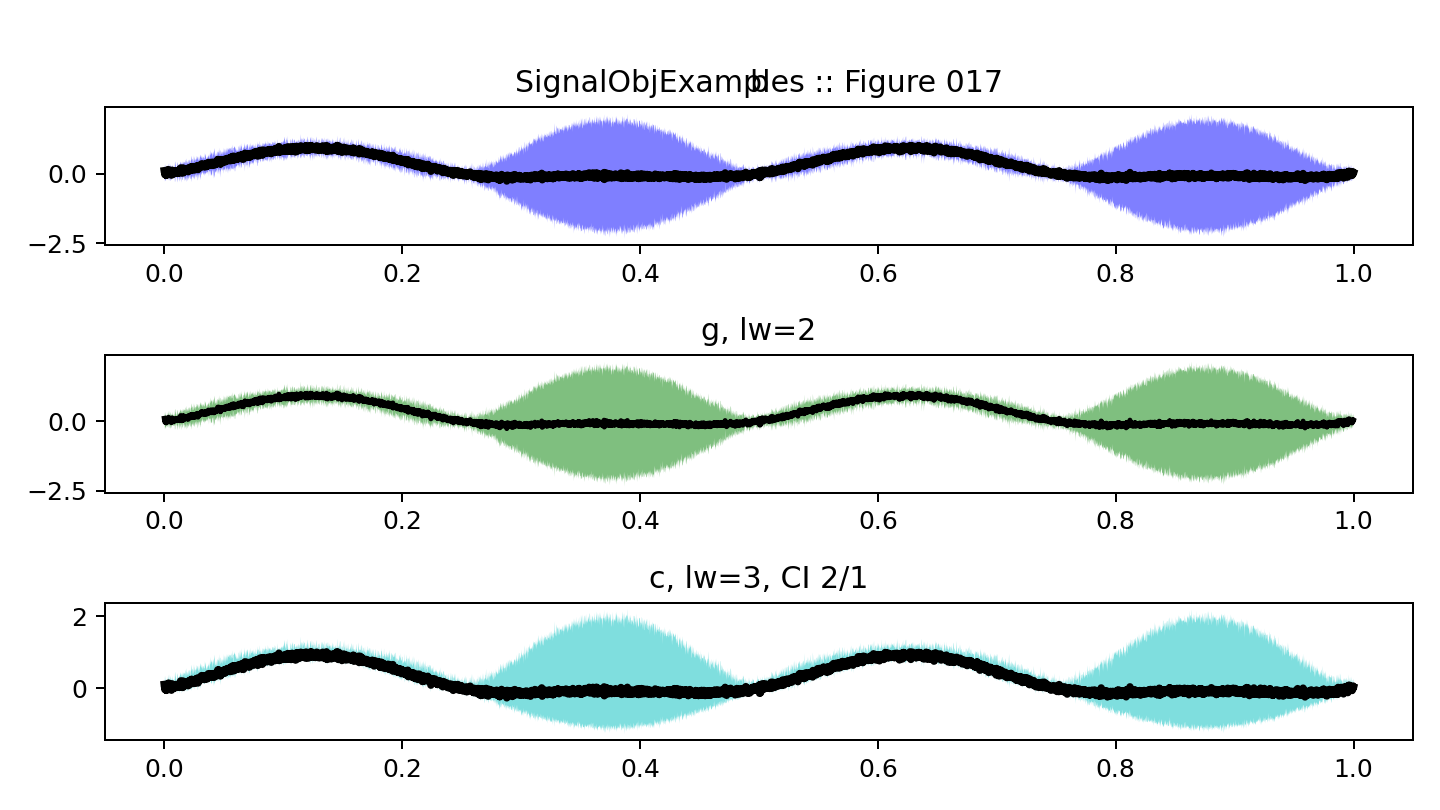

In [ ]:
# Example 6: Signal Variability
sampleRate6 = 5000
t6 = np.arange(0, 1 + 1 / sampleRate6, 1 / sampleRate6)
v1b = np.sin(2 * np.pi * 2 * t6)
v2b = np.sin(v1b ** 2)
noise = 0.1 * np.random.randn(len(t6), 6)
data = np.vstack([v1b, v2b, v2b, v1b, v2b, v1b]).T + noise
sv = SignalObj(t6, data.T, "Voltage", "time", "s", "V", ["v1", "v2", "v2", "v1", "v1", "v2"])
__tracker.new_figure("Example 6: signals + all-variability")
plt.subplot(2, 1, 1); sv.plot(); plt.title("noisy signals")
plt.subplot(2, 1, 2); sv.plotAllVariability(); plt.title("plotAllVariability")
plt.tight_layout()

__tracker.new_figure("Example 6: per-label variability")
sv.plotVariability(); plt.title("plotVariability (by label)")
plt.tight_layout()

__tracker.new_figure("Example 6: customized variability bands")
plt.subplot(3, 1, 1); sv.plotAllVariability("b"); plt.title("b")
plt.subplot(3, 1, 2); sv.plotAllVariability("g", 2); plt.title("g, lw=2")
plt.subplot(3, 1, 3); sv.plotAllVariability("c", 3, 2, 1); plt.title("c, lw=3, CI 2/1")
plt.tight_layout()

__tracker.finalize()
